# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-11: Algoritmo de Simon (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-11.

---

### Posición en la genealogía de algoritmos cuánticos

```
Deutsch-Jozsa → Bernstein-Vazirani → Simon → Shor
```

Simon fue el primero en demostrar una ventaja cuántica **exponencial** sobre algoritmos clásicos — no solo un factor constante o polinomial. Shor tomó las ideas de Simon para construir el algoritmo de factorización que rompería RSA.

---

### Problema que resuelve

Dada una función de caja negra $f: \{0,1\}^n \rightarrow \{0,1\}^n$ con la garantía de que es una de estas dos:
- **Inyectiva (1 a 1):** cada entrada tiene una salida única → $s = 00\ldots0$
- **2 a 1:** existe una cadena secreta $s \neq 0$ tal que $f(x) = f(x \oplus s)$ para todo $x$

El objetivo es determinar $s$.

**Clásicamente:** para encontrar dos entradas $x_1, x_2$ con $f(x_1) = f(x_2)$ se aplica la paradoja del cumpleaños — se necesitan $O(2^{n/2})$ consultas en el peor caso (evaluar suficientes entradas hasta que colisionen dos salidas).  
**Cuánticamente:** $O(n)$ consultas al oráculo + resolución de un sistema lineal mod 2.

---

### Pasos del algoritmo

| Paso | Acción | Estado |
|---|---|---|
| 0 | $n$ qubits de entrada $\vert 0\rangle^n$ + $n$ qubits objetivo $\vert 0\rangle^n$ | $\vert 0\rangle^n \vert 0\rangle^n$ |
| 1 | H en cada qubit de entrada | $\frac{1}{\sqrt{2^n}}\sum_x \vert x\rangle\vert 0\rangle^n$ |
| 2 | Oracle $U_f$: $\vert x\rangle\vert 0\rangle \rightarrow \vert x\rangle\vert f(x)\rangle$ | $\frac{1}{\sqrt{2^n}}\sum_x \vert x\rangle\vert f(x)\rangle$ |
| 3 | H en cada qubit de entrada | Interferencia: solo $z$ con $z \odot s = 0$ tienen amplitud ≠ 0 |
| 4 | Medir todos los qubits | Se obtiene un par $(z, f(x))$ con $z \odot s = 0$ |
| 5 | Repetir $n$ veces y resolver $\{z^{(i)} \odot s = 0\}$ | Se recupera $s$ con eliminación gaussiana |

> **Diferencia clave con Bernstein-Vazirani:** no hay phase kickback. Los qubits objetivo se inicializan en $\vert 0\rangle$ y almacenan $f(x)$ directamente. La información de $s$ emerge de la interferencia en los qubits de entrada tras el segundo H.

---

### Implementación: $s = 110$, $n = 3$ qubits

La función implementada es 2 a 1 con secreto $s = 110$, lo que significa $f(x) = f(x \oplus 110)$ para todo $x$. Los resultados de la medición corresponden a pares $(z, f(x))$ donde $z \odot 110 = z_0 \oplus z_1 = 0$, es decir $z_0 = z_1$. Los únicos $z$ posibles son:

$$z \in \{000, 001, 110, 111\}$$

Con múltiples mediciones y eliminación gaussiana mod 2 sobre las ecuaciones $z \odot s = 0$ se recupera $s = 110$.

---

### Erratas del libro corregidas

| Libro | Corrección | Motivo |
|---|---|---|
| `"{0:b}".format(k)` sin zero-padding | `format(k, f'0{2*n}b')` | Sin padding `'000'` aparece como `'0'` |
| `2*num_qubits – len(new_key)` con en-dash `–` | `2*n - len(...)` con guión `-` | `–` no es un operador Python válido |

---

### Explicación profunda del algoritmo

#### El problema en términos concretos

Imagina que tienes una función $f$ que actúa como una máquina: le metes una cadena de bits y te devuelve otra. La máquina tiene un secreto $s$ grabado internamente que determina su comportamiento: **para cualquier entrada $x$, la máquina produce exactamente la misma salida para $x$ y para $x \oplus s$**.

Esto significa que las entradas vienen en parejas — cada pareja comparte una salida y sus dos miembros siempre difieren en exactamente las posiciones donde $s$ tiene un 1.

Para $s = 110$ las parejas son:

| Pareja | Entrada $x$ | $x \oplus 110$ | Salen igual |
|:---:|:---:|:---:|:---:|
| 1 | $000$ | $110$ | $f(000) = f(110)$ |
| 2 | $001$ | $111$ | $f(001) = f(111)$ |
| 3 | $010$ | $100$ | $f(010) = f(100)$ |
| 4 | $011$ | $101$ | $f(011) = f(101)$ |

Observa que en cada fila, las dos entradas difieren exactamente en los bits 0 y 1 — las posiciones donde $s = 110$ tiene un 1. El bit 2 nunca cambia entre los dos miembros de la pareja porque $s_2 = 0$.

No tienes acceso al interior de la máquina — solo puedes introducir entradas y observar salidas. El reto es descubrir $s$ consultando la máquina el menor número de veces posible.

---

#### Por qué es difícil clásicamente

Como la función es una caja negra, la única estrategia clásica es evaluar entradas una a una y esperar que dos produzcan la misma salida. Cuando eso ocurre, $x_1 \oplus x_2 = s$.

Esto es exactamente el problema del cumpleaños: en un grupo de personas, ¿cuántas hacen falta para que dos compartan cumpleaños? La respuesta es $O(\sqrt{N})$, mucho menos que $N$ personas, pero sigue creciendo con $N$.

Aquí $N = 2^n$, así que clásicamente necesitas evaluar $O(2^{n/2})$ entradas antes de esperar una colisión. Para $n = 100$ eso son $2^{50} \approx 10^{15}$ evaluaciones — computacionalmente inviable.

---

#### Cómo se recupera $s$ de las mediciones

Cada ejecución del circuito produce un valor $z$ con la garantía matemática de que $z \odot s = 0$ (producto punto mod 2). Esto es una ecuación lineal sobre los bits de $s$.

Repitiendo $n$ veces y recogiendo $n$ valores $z$ independientes obtienes un sistema:

$$z^{(1)} \odot s = 0 \quad z^{(2)} \odot s = 0 \quad \cdots \quad z^{(n)} \odot s = 0$$

Este sistema se resuelve con eliminación gaussiana mod 2 para encontrar $s$.

Para $s = 110$: la condición $z \odot 110 = z_0 + z_1 \pmod{2} = 0$ implica que $z_0 = z_1$. Los únicos $z$ posibles son $\{000, 001, 110, 111\}$ — exactamente los cuatro que el histograma muestra con distribución uniforme.

Una forma más directa: buscar dos resultados que tengan el mismo $f(x)$ (los últimos 3 bits del resultado) y calcular $x_1 \oplus x_2$ — eso da $s$ directamente sin resolver el sistema.

---

#### La ventaja exponencial resumida

| | Clásico | Cuántico |
|---|:---:|:---:|
| Consultas al oráculo | $O(2^{n/2})$ | $O(n)$ |
| Para $n=100$ | $\sim 10^{15}$ operaciones | $\sim 100$ operaciones |

### Oráculo para $s = 110$

El oráculo implementa $f: \{0,1\}^3 \rightarrow \{0,1\}^3$ tal que $f(x) = f(x \oplus 110)$.  
Está construido con puertas CNOT y Toffoli (CCNOT). Cada puerta y su efecto se documenta abajo.

In [16]:
import cirq
import numpy as np


def oracle(input_qubits, target_qubits, circuit):
    """
    Oracle para la cadena secreta s = 110.
    Implementa f tal que f(x) = f(x XOR 110) para todo x.

    Notación: in[i] = input_qubits[i], tgt[j] = target_qubits[j]
    """
    # tgt[1] ← tgt[1] XOR in[2]  (copia el bit 2 de entrada al bit 1 del objetivo)
    circuit.append(cirq.CNOT(input_qubits[2], target_qubits[1]))

    # tgt[0] ← NOT tgt[0]  (invierte el bit 0 del objetivo)
    circuit.append(cirq.X(target_qubits[0]))

    # tgt[0] ← tgt[0] XOR in[2]
    circuit.append(cirq.CNOT(input_qubits[2], target_qubits[0]))

    # tgt[0] ← tgt[0] XOR (in[0] AND in[1])  (Toffoli: flipa si in[0]=in[1]=1)
    circuit.append(cirq.CCNOT(input_qubits[0], input_qubits[1], target_qubits[0]))

    # Invertir in[0] e in[1] temporalmente para evaluar el caso in[0]=in[1]=0
    circuit.append(cirq.X(input_qubits[0]))
    circuit.append(cirq.X(input_qubits[1]))

    # tgt[0] ← tgt[0] XOR (NOT in[0] AND NOT in[1])  (flipa si in[0]=in[1]=0 original)
    circuit.append(cirq.CCNOT(input_qubits[0], input_qubits[1], target_qubits[0]))

    # Restaurar in[0] e in[1]
    circuit.append(cirq.X(input_qubits[0]))
    circuit.append(cirq.X(input_qubits[1]))

    # tgt[0] ← NOT tgt[0]  (inversión final para completar la función)
    circuit.append(cirq.X(target_qubits[0]))

    return circuit

### Circuito principal

In [17]:
def simons_algorithm_circuit(num_qubits=3, copies=1000):
    """
    Construye y ejecuta el circuito del algoritmo de Simon.

    num_qubits: número de qubits de entrada (= número de qubits objetivo)
    copies:     repeticiones de la simulación

    Retorna: (circuit, result)
    """
    input_qubits  = [cirq.LineQubit(i) for i in range(num_qubits)]
    target_qubits = [cirq.LineQubit(k) for k in range(num_qubits, 2 * num_qubits)]

    circuit = cirq.Circuit()

    # Paso 1: superposición uniforme en los qubits de entrada
    circuit.append(cirq.H(q) for q in input_qubits)

    # Paso 2: oracle — computa f(x) y lo almacena en los qubits objetivo
    # Los qubits objetivo quedan en |f(x)⟩ sin phase kickback
    circuit = oracle(input_qubits, target_qubits, circuit)

    # Paso 3: H en los qubits de entrada → interferencia
    # Solo los z con z·s = 0 (mod 2) tienen amplitud no nula
    circuit.append(cirq.H(q) for q in input_qubits)

    # Paso 4: medir todos los qubits (entrada + objetivo)
    circuit.append(cirq.measure(*(input_qubits + target_qubits), key='Z'))

    sim = cirq.Simulator()
    result = sim.run(circuit, repetitions=copies)

    return circuit, result, num_qubits

In [18]:
circuit, result, n = simons_algorithm_circuit(num_qubits=3, copies=1000)
print(circuit)

                  ┌──┐
0: ───H────────────@─────X───@───X───H───M('Z')───
                   │         │           │
1: ───H────────────@─────X───@───X───H───M────────
                   │         │           │
2: ───H───@───@────┼H────────┼───────────M────────
          │   │    │         │           │
3: ───X───┼───X────X─────────X───X───────M────────
          │                              │
4: ───────X──────────────────────────────M────────
                                         │
5: ──────────────────────────────────────M────────
                  └──┘


### Visualización del circuito

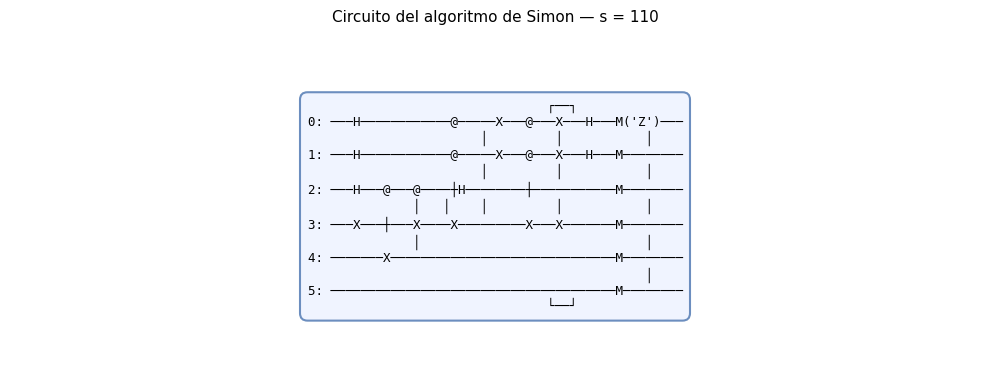

In [19]:
import matplotlib.pyplot as plt

diagrama = circuit.to_text_diagram()

fig, ax = plt.subplots(figsize=(10, 4))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=9,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title('Circuito del algoritmo de Simon — s = 110', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Resultados de la medición

Cada resultado es una cadena de 6 bits: los 3 primeros son los qubits de entrada $z$, los 3 últimos son los qubits objetivo $f(x)$.

In [20]:
out = dict(result.histogram(key='Z'))

# Convertir enteros a cadenas binarias con zero-padding correcto
out_result = {format(k, f'0{2*n}b'): v for k, v in out.items()}

print(f"Resultados (input|target) — {len(out_result)} combinaciones distintas:")
for bitstring, count in sorted(out_result.items()):
    z   = bitstring[:n]   # qubits de entrada (medir z)
    fx  = bitstring[n:]   # qubits objetivo (valor de f(x))
    print(f"  z={z}  f(x)={fx}  →  {count} veces")

Resultados (input|target) — 16 combinaciones distintas:
  z=000  f(x)=000  →  52 veces
  z=000  f(x)=010  →  65 veces
  z=000  f(x)=100  →  56 veces
  z=000  f(x)=110  →  61 veces
  z=001  f(x)=000  →  54 veces
  z=001  f(x)=010  →  66 veces
  z=001  f(x)=100  →  66 veces
  z=001  f(x)=110  →  79 veces
  z=110  f(x)=000  →  67 veces
  z=110  f(x)=010  →  62 veces
  z=110  f(x)=100  →  58 veces
  z=110  f(x)=110  →  67 veces
  z=111  f(x)=000  →  53 veces
  z=111  f(x)=010  →  77 veces
  z=111  f(x)=100  →  56 veces
  z=111  f(x)=110  →  61 veces


### Distribución de los valores $z$ medidos

Para $s = 110$, la condición $z \odot s = 0$ se reduce a $z_0 \oplus z_1 = 0$, es decir $z_0 = z_1$.  
Los únicos valores posibles son $z \in \{000, 001, 110, 111\}$ — con distribución uniforme entre ellos.

Distribución de z (qubits de entrada):
  z=000  z·s=0  →  234 veces
  z=001  z·s=0  →  265 veces
  z=110  z·s=0  →  254 veces
  z=111  z·s=0  →  247 veces


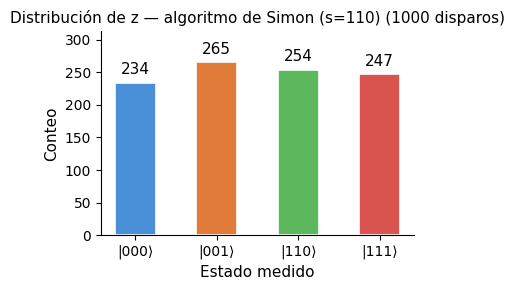

In [21]:
from qml_santanu.common.plot_utils import plot_counts

# Agregar conteos por valor de z (ignorar el valor de f(x))
z_counts = {}
for bitstring, count in out_result.items():
    z = bitstring[:n]
    z_counts[z] = z_counts.get(z, 0) + count

print("Distribución de z (qubits de entrada):")
for z, count in sorted(z_counts.items()):
    dot_s = (int(z[0]) + int(z[1])) % 2  # z · 110 = z0 XOR z1
    print(f"  z={z}  z·s={dot_s}  →  {count} veces")

plot_counts(z_counts, title='Distribución de z — algoritmo de Simon (s=110)')

### Recuperación de $s$ a partir de los resultados

Cada medición produce un $z$ tal que $z \odot s = 0$. Con los $z$ únicos observados buscamos qué $s \neq 000$ satisface todas las ecuaciones simultáneamente.

Para $n$ pequeño basta una búsqueda exhaustiva sobre los $2^n - 1$ candidatos no triviales.

In [22]:
z_values = list(z_counts.keys())  # valores z únicos observados

candidatos = []
for s_int in range(1, 2**n):  # probar todos los s != 000
    s_bits = format(s_int, f'0{n}b')
    # s es válido si z·s = 0 para todos los z observados
    if all(sum(int(z[i]) * int(s_bits[i]) for i in range(n)) % 2 == 0
           for z in z_values):
        candidatos.append(s_bits)

print(f"Cadena secreta recuperada: {candidatos}")
print(f"Cadena secreta real:       110")

Cadena secreta recuperada: ['110']
Cadena secreta real:       110


### Verificación: $z \odot s = 0$ para todos los $z$ observados

In [23]:
S = '110'
print(f"Verificando z · s = 0 (mod 2) para s = {S}:\n")

todos_validos = True
for z in sorted(z_counts):
    dot = sum(int(z[i]) * int(S[i]) for i in range(n)) % 2
    estado = '✓' if dot == 0 else '✗'
    print(f"  z={z}  ·  s={S}  =  {dot}  {estado}")
    if dot != 0:
        todos_validos = False

print(f"\nTodos los z satisfacen z·s=0: {todos_validos}")

Verificando z · s = 0 (mod 2) para s = 110:

  z=000  ·  s=110  =  0  ✓
  z=001  ·  s=110  =  0  ✓
  z=110  ·  s=110  =  0  ✓
  z=111  ·  s=110  =  0  ✓

Todos los z satisfacen z·s=0: True


---

### Conclusión

**¿Para qué sirve el algoritmo de Simon?**

El único objetivo del algoritmo es encontrar la cadena secreta $s$ de una función que satisface $f(x) = f(x \oplus s)$. Nada más, nada menos.

**Lo que el algoritmo sí hace:**
- Encuentra $s$ con $O(n)$ consultas al oráculo cuántico
- Si el resultado es $s = 00\ldots0$, la función es inyectiva (1 a 1)
- Si el resultado es $s \neq 00\ldots0$, la función es 2 a 1 y $s$ es la cadena que empareja entradas

**Lo que el algoritmo NO hace:**
- No evalúa $f(x)$ para ninguna entrada específica
- No sirve para funciones sin la estructura $f(x) = f(x \oplus s)$

**Por qué la ventaja cuántica es irreducible:**

Clásicamente, encontrar $s$ obliga a buscar colisiones — dos entradas con la misma salida — lo que requiere $O(2^{n/2})$ consultas por la paradoja del cumpleaños. No existe ningún atajo clásico: incluso con la mejor estrategia posible, el coste crece exponencialmente con $n$.

Simon demostró por primera vez que hay problemas donde la ventaja cuántica es exponencial y matemáticamente inevitable, no una mejora de constantes o un truco de implementación.

**La importancia histórica:**

En criptografía, muchas funciones de cifrado tienen estructura periódica similar a la de Simon. Si puedes encontrar el período de una función de cifrado, puedes romperla. Simon abrió la pregunta: ¿la factorización de enteros — que también tiene estructura periódica — podría atacarse de forma similar?

Esa pregunta tiene respuesta, y se llama el algoritmo de Shor.